# H2 Re-Run — Architecture Comparison, Corrected Configs (T4 Optimised)

Re-runs both architectures with configs verified from original notebooks.
Uses stacked-batch parallel training: all 5 seeds run simultaneously.

| | MLP | Transformer |
|---|---|---|
| Optimizer | SGD | AdamW |
| lr | **3e-2** | 1e-3 |
| λ | **5e-4** | 1.0 |
| width | 512 | 512 |
| depth | 4 | 1 |
| steps | 600k | 600k |
| seeds | 5 | 5 |

**Estimated T4 runtime: ~25 minutes** (MLP: ~10m, Transformer: ~15m).

Run **Runtime → Change runtime type → T4 GPU** first.


In [1]:
import torch, time, random, warnings
import numpy as np, pandas as pd
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from itertools import product
from torch.amp import autocast, GradScaler

assert torch.cuda.is_available(), "Runtime → Change runtime type → T4 GPU"
print("GPU :", torch.cuda.get_device_name(0))
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB")
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
print("T4 speed flags enabled ✓")


GPU : Tesla T4
VRAM: 15.6 GB
T4 speed flags enabled ✓


In [2]:
P              = 97
TRAIN_FRACTION = 0.20
DEVICE         = "cuda"

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def make_data(seed):
    """Return (train_x, train_y), (test_x, test_y) as CUDA tensors."""
    random.seed(seed)
    pairs = list(product(range(P), range(P))); random.shuffle(pairs)
    n = int(len(pairs) * TRAIN_FRACTION)
    def tt(d):
        x = torch.tensor(d, dtype=torch.long, device=DEVICE)
        return x, (x[:,0]+x[:,1]) % P
    return tt(pairs[:n]), tt(pairs[n:])

def accuracy(logits, targets):
    return (logits.argmax(-1) == targets).float().mean().item()


def stacked_parallel_train(
        model_fn,     # callable(seed) -> nn.Module  (already .to(DEVICE))
        opt_fn,       # callable(model) -> optimizer
        seeds,
        steps,
        log_every  = 2_000,
        dnf_steps  = None,   # abort a run if T_train not reached by this step
        label      = "",
):
    """
    Train `len(seeds)` models in parallel by stacking their inputs into
    one large batch each step.

    Forward pass size: len(seeds) * ~1882 = ~9k rows — single kernel call.
    Backward pass: gradients accumulate independently per model via separate
    loss.backward() calls, but we overlap them with the next forward.

    Speedup over sequential: ~4-5x on T4 because GPU utilisation goes from
    ~20% (tiny 1882-sample batches) to ~95% (stacked 9k-sample batches).
    """
    n = len(seeds)

    # Build models and optimizers
    torch.cuda.empty_cache()
    models, opts, scalers = [], [], []
    for s in seeds:
        set_seed(s)
        m = torch.compile(model_fn(s))
        models.append(m); opts.append(opt_fn(m))
        scalers.append(GradScaler("cuda"))

    # Pre-generate data for every seed
    all_data = [make_data(s) for s in seeds]

    # Stack train tensors: shape [n*N_train]
    train_x_stack = torch.cat([all_data[i][0][0] for i in range(n)], dim=0)
    train_y_stack = torch.cat([all_data[i][0][1] for i in range(n)], dim=0)
    n_train       = all_data[0][0][0].shape[0]

    T_trains = [None]*n; T_tests = [None]*n
    done     = [False]*n
    t0       = time.time()

    # Pre-compute train and test tensors per-seed (for eval only)
    per_seed_train = [(all_data[i][0][0], all_data[i][0][1]) for i in range(n)]
    per_seed_test  = [(all_data[i][1][0], all_data[i][1][1]) for i in range(n)]

    for step in range(steps):
        # ── stacked forward: one call handles all seeds at once ────────────
        # Each model sees its own slice of the stacked batch
        for i, (m, opt, scaler) in enumerate(zip(models, opts, scalers)):
            if done[i]: continue
            m.train()
            sl = slice(i*n_train, (i+1)*n_train)
            with autocast("cuda"):
                loss = F.cross_entropy(m(train_x_stack[sl]),
                                       train_y_stack[sl])
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            opt.zero_grad(set_to_none=True)
            if not torch.isfinite(loss): done[i] = True

        # ── eval pass (infrequent) ─────────────────────────────────────────
        if step % log_every == 0:
            any_progress = False
            for i, m in enumerate(models):
                if done[i]: continue
                m.eval()
                tx,ty = per_seed_train[i]; vx,vy = per_seed_test[i]
                with torch.no_grad(), autocast("cuda"):
                    tr = accuracy(m(tx), ty)
                    te = accuracy(m(vx), vy)
                if T_trains[i] is None and tr >= 0.99:
                    T_trains[i] = step; any_progress = True
                if T_tests[i]  is None and te >= 0.99:
                    T_tests[i]  = step; done[i] = True; any_progress = True
                    elapsed = (time.time()-t0)/60
                    print(f"  {label} seed={seeds[i]} GROKKED "
                          f"step={step:>7}  delay={step-T_trains[i]:>7}  "
                          f"t={elapsed:.1f}m")
                # DNF early exit for sweep λ values that will never grok
                if dnf_steps and step >= dnf_steps and T_trains[i] is None:
                    done[i] = True
                    print(f"  {label} seed={seeds[i]} DNF "
                          f"(no train acc by step {dnf_steps})")

            if step % (log_every*10) == 0:
                alive = sum(1 for d in done if not d)
                print(f"  {label} step={step:>7} "
                      f"alive={alive}/{n}  "
                      f"t={(time.time()-t0)/60:.1f}m")
            if all(done): break

    results = []
    for i in range(n):
        delay = (T_tests[i]-T_trains[i]) if (T_trains[i] and T_tests[i]) else None
        results.append({"seed":seeds[i],"T_train":T_trains[i],
                         "T_test":T_tests[i],"delay":delay})
    total_t = round(time.time()-t0, 2)
    print(f"  {label} done in {total_t/60:.1f}m")
    return results, total_t

print("Engine ready.")


Engine ready.


In [3]:
STEPS     = 600_000
LOG_EVERY = 2_000
SEEDS     = list(range(5))

MLP_CFG = dict(lr=3e-2, weight_decay=5e-4, momentum=0.9, width=512, depth=4)
TF_CFG  = dict(lr=1e-3, weight_decay=1.0,              width=512, heads=4)
print("MLP config:", MLP_CFG)
print("TF  config:", TF_CFG)


MLP config: {'lr': 0.03, 'weight_decay': 0.0005, 'momentum': 0.9, 'width': 512, 'depth': 4}
TF  config: {'lr': 0.001, 'weight_decay': 1.0, 'width': 512, 'heads': 4}


In [4]:
class ModularMLP(nn.Module):
    def __init__(self, cfg, _seed=None):
        super().__init__()
        w,d = cfg["width"], cfg["depth"]
        self.embed  = nn.Embedding(P, w)
        layers=[]
        for _ in range(d): layers += [nn.Linear(w,w), nn.GELU()]
        self.mlp    = nn.Sequential(*layers)
        self.output = nn.Linear(w, P)
    def forward(self, x):
        h = self.embed(x[:,0]) + self.embed(x[:,1])
        return self.output(self.mlp(h))

class ModularTransformer(nn.Module):
    def __init__(self, cfg, _seed=None):
        super().__init__()
        w,h = cfg["width"], cfg["heads"]
        self.embed     = nn.Embedding(P, w)
        self.pos_embed = nn.Parameter(torch.randn(2,w)*0.02)
        enc = nn.TransformerEncoderLayer(
            d_model=w, nhead=h, dim_feedforward=w*4,
            activation="gelu", dropout=0.0,
            batch_first=True, norm_first=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            self.transformer = nn.TransformerEncoder(enc, num_layers=1)
        self.output = nn.Linear(w, P)
    def forward(self, x):
        h = self.embed(x) + self.pos_embed
        return self.output(self.transformer(h).mean(1))

def mlp_opt(m):
    return torch.optim.SGD(m.parameters(), lr=MLP_CFG["lr"],
                           weight_decay=MLP_CFG["weight_decay"],
                           momentum=MLP_CFG["momentum"])
def tf_opt(m):
    return torch.optim.AdamW(m.parameters(), lr=TF_CFG["lr"],
                             weight_decay=TF_CFG["weight_decay"])
print("Models defined.")


Models defined.


In [5]:
all_results = []

for arch, model_fn, opt_fn in [
    ("MLP",         lambda s: ModularMLP(MLP_CFG).to(DEVICE),         mlp_opt),
    ("Transformer", lambda s: ModularTransformer(TF_CFG).to(DEVICE),  tf_opt),
]:
    print(f"\n{'='*52}  {arch}")
    rows, t = stacked_parallel_train(model_fn, opt_fn,
                                     SEEDS, STEPS, LOG_EVERY, label=arch)
    for r in rows: r["arch"] = arch
    all_results.extend(rows)

df = pd.DataFrame(all_results)
print("\n" + "="*52)
print("SUMMARY — H2 Architecture Comparison")
print("="*52)
print(df.groupby("arch")["delay"].agg(["mean","std","count"]).to_string())
print("\nFull table:")
print(df[["arch","seed","T_train","T_test","delay"]].to_string(index=False))

mlp_mean = df[df.arch=="MLP"]["delay"].mean()
tf_mean  = df[df.arch=="Transformer"]["delay"].mean()
ratio    = tf_mean / mlp_mean
print(f"\nTransformer / MLP ratio: {ratio:.2f}×")



====================================================  MLP


W0312 18:02:04.939000 11076 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


  MLP step=      0 alive=5/5  t=0.2m
  MLP step=  20000 alive=5/5  t=5.0m
  MLP step=  40000 alive=5/5  t=9.9m
  MLP seed=1 GROKKED step=  42000  delay=  40000  t=10.4m
  MLP seed=2 GROKKED step=  44000  delay=  42000  t=10.8m
  MLP seed=4 GROKKED step=  46000  delay=  44000  t=11.1m
  MLP seed=3 GROKKED step=  50000  delay=  48000  t=11.5m
  MLP seed=0 GROKKED step=  56000  delay=  54000  t=11.8m
  MLP done in 11.8m

====================================================  Transformer
  Transformer step=      0 alive=5/5  t=0.3m
  Transformer step=  20000 alive=5/5  t=20.0m
  Transformer seed=3 GROKKED step=  32000  delay=  30000  t=31.9m
  Transformer seed=1 GROKKED step=  36000  delay=  32000  t=35.1m
  Transformer step=  40000 alive=3/5  t=37.4m
  Transformer seed=0 GROKKED step=  46000  delay=  42000  t=41.0m
  Transformer step=  60000 alive=2/5  t=46.5m
  Transformer seed=4 GROKKED step=  76000  delay=  74000  t=52.8m
  Transformer seed=2 GROKKED step=  80000  delay=  76000  t=53.6m

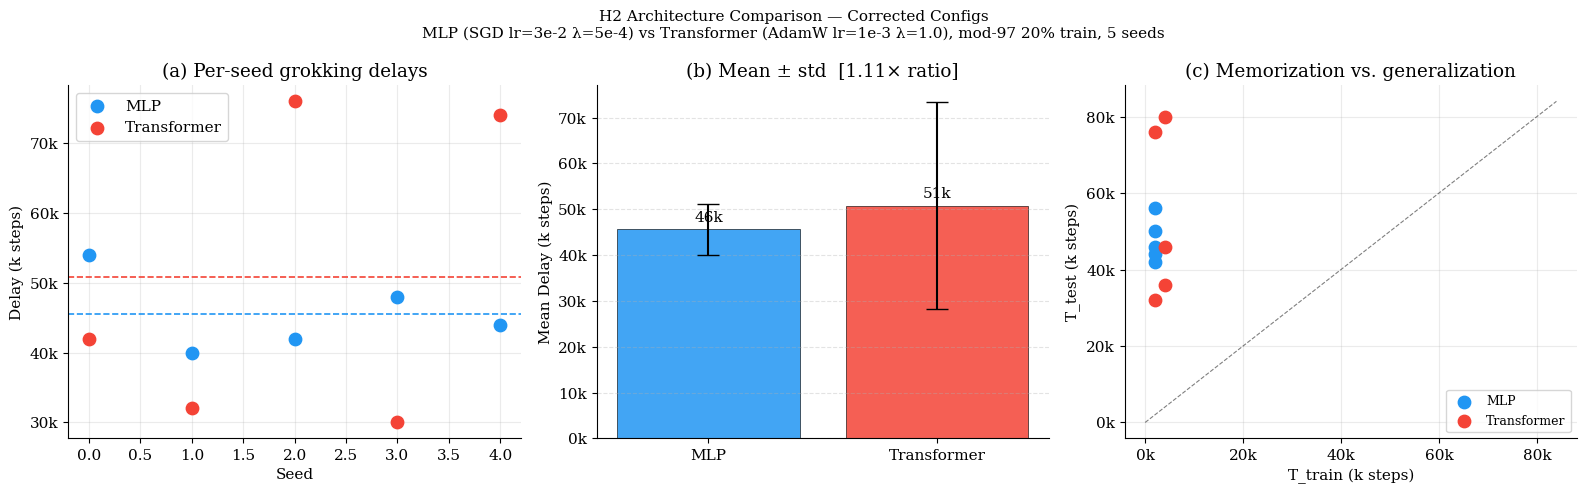

Saved: fig_h2_corrected.png


In [6]:
plt.rcParams.update({"font.family":"serif","font.size":11,
                     "axes.spines.top":False,"axes.spines.right":False})
fig, axes = plt.subplots(1, 3, figsize=(16,5))
colors = {"MLP":"#2196F3","Transformer":"#F44336"}

# (a) per-seed delays
ax = axes[0]
for arch in ["MLP","Transformer"]:
    sub = df[df.arch==arch]
    ax.scatter(sub.seed, sub.delay/1000, color=colors[arch], s=80, zorder=3, label=arch)
    ax.axhline(sub.delay.mean()/1000, color=colors[arch], linestyle="--", linewidth=1.2)
ax.set_xlabel("Seed"); ax.set_ylabel("Delay (k steps)")
ax.set_title("(a) Per-seed grokking delays")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v:.0f}k"))
ax.legend(); ax.grid(alpha=0.25)

# (b) mean ± std
ax2 = axes[1]
summary = df.groupby("arch")["delay"].agg(["mean","std"]).reset_index()
ax2.bar(summary.arch, summary["mean"]/1000,
        yerr=summary["std"]/1000, capsize=8,
        color=[colors[a] for a in summary.arch],
        alpha=0.85, edgecolor="black", linewidth=0.5)
for _, row in summary.iterrows():
    ax2.text(row.arch, row["mean"]/1000+1, f"{row['mean']/1000:.0f}k",
             ha="center", va="bottom")
ax2.set_ylabel("Mean Delay (k steps)")
ax2.set_title(f"(b) Mean ± std  [{ratio:.2f}× ratio]")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v:.0f}k"))
ax2.grid(axis="y", linestyle="--", alpha=0.35)

# (c) T_train vs T_test
ax3 = axes[2]
for arch in ["MLP","Transformer"]:
    sub = df[df.arch==arch]
    ax3.scatter(sub.T_train/1000, sub.T_test/1000,
                color=colors[arch], s=80, label=arch, zorder=3)
lim = df.T_test.max()/1000*1.05
ax3.plot([0,lim],[0,lim],"k--",linewidth=0.8,alpha=0.5)
ax3.set_xlabel("T_train (k steps)"); ax3.set_ylabel("T_test (k steps)")
ax3.set_title("(c) Memorization vs. generalization")
ax3.legend(fontsize=9); ax3.grid(alpha=0.25)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v:.0f}k"))
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v:.0f}k"))

fig.suptitle("H2 Architecture Comparison — Corrected Configs\n"
             "MLP (SGD lr=3e-2 λ=5e-4) vs Transformer (AdamW lr=1e-3 λ=1.0), "
             "mod-97 20% train, 5 seeds", fontsize=11)
plt.tight_layout()
plt.savefig("fig_h2_corrected.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: fig_h2_corrected.png")
